<a href="https://colab.research.google.com/github/orenlevis/HiggsPeak_StatsProject/blob/main/Data_Extraction_Muon_2012B_with_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.4/395.4 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 20.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install awkward_pandas

In [4]:
import uproot
import numpy as np
import pandas as pd
import awkward as ak

In [5]:
file = uproot.open("/content/drive/MyDrive/HiggsExample/true_rootfiles/Run2012B_DoubleMuParked.root")
tree = file["Events"]

data_muon = tree.arrays(["Muon_pt", "Muon_eta", "Muon_phi", "Muon_mass", "nMuon"], library="pd")

**Note**: The raw data file contains about 3mil datapoints, so it is very computationally expensive to analyse them using Python (the cell was still running after ~20mins). Here we decided to sample 300,000 points randomly to match the length of the other datasets (simulated Higgs and electrons).

This code runs for **two** samples ("sample1", "sample2") and compares the final plots as a first diagnostic. More detailed comparison could follow from fitting and obtaining statistsics.



In [6]:
num = data_muon["nMuon"]
good_muon = data_muon[num == 4] # select events with exactly 4 muons
good_muon_sample_1 = good_muon.sample(n=300000, random_state=42)
good_muon_sample_2 = good_muon.sample(n=300000, random_state=73)

In [8]:
# Convert the columns back to awkward arrays for vectorized math on jagged data
# We use ak.from_iter because the pandas cells contain list objects
# Analysis of dataset 1
m_pt_1 = ak.from_iter(good_muon_sample_1['Muon_pt'])
m_phi_1 = ak.from_iter(good_muon_sample_1['Muon_phi'])
m_eta_1 = ak.from_iter(good_muon_sample_1['Muon_eta'])

# Now you can do math directly!
muon_px_1 = m_pt_1 * np.cos(m_phi_1)
muon_py_1 = m_pt_1 * np.sin(m_phi_1)
muon_pz_1 = m_pt_1 * np.sinh(m_eta_1)

In [9]:
# Analysis of dataset 2
m_pt_2 = ak.from_iter(good_muon_sample_2['Muon_pt'])
m_phi_2 = ak.from_iter(good_muon_sample_2['Muon_phi'])
m_eta_2 = ak.from_iter(good_muon_sample_2['Muon_eta'])

muon_px_2 = m_pt_2 * np.cos(m_phi_2)
muon_py_2 = m_pt_2 * np.sin(m_phi_2)
muon_pz_2 = m_pt_2 * np.sinh(m_eta_2)

In [10]:
# To calculate invariant mass, we need the energy of each particle.
# E = sqrt(p^2 + m^2)
# ANALYSIS OF SET 1
m_mass_1 = ak.from_iter(good_muon_sample_1['Muon_mass'])

muon_e_1 = np.sqrt(muon_px_1**2 + muon_py_1**2 + muon_pz_1**2 + m_mass_1**2)

In [11]:
# ANALYSIS OF SET 2
m_mass_2 = ak.from_iter(good_muon_sample_2['Muon_mass'])

muon_e_2 = np.sqrt(muon_px_2**2 + muon_py_2**2 + muon_pz_2**2 + m_mass_2**2)

In [12]:
total_px_1 = ak.sum(muon_px_1, axis=1)
total_py_1 = ak.sum(muon_py_1, axis=1)
total_pz_1 = ak.sum(muon_pz_1, axis=1)
total_e_1 = ak.sum(muon_e_1, axis=1)

total_px_2 = ak.sum(muon_px_2, axis=1)
total_py_2 = ak.sum(muon_py_2, axis=1)
total_pz_2 = ak.sum(muon_pz_2, axis=1)
total_e_2 = ak.sum(muon_e_2, axis=1)

# Calculate invariant mass for every event at once
m_4l_1 = np.sqrt(total_e_1**2 - (total_px_1**2 + total_py_1**2 + total_pz_1**2))
m_4l_2 = np.sqrt(total_e_2**2 - (total_px_2**2 + total_py_2**2 + total_pz_2**2))

Calculated masses for 300000 events.
First 10 mass values:
[41.9, 22.5, 11.3, 146, 86.2, 131, 126, 26.9, 99.6, 48.5]


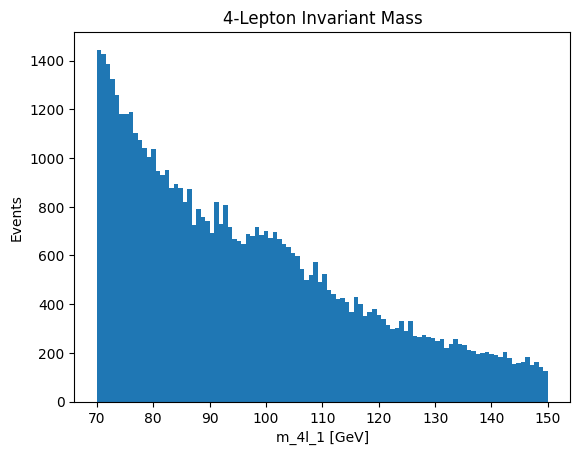

Calculated masses for 300000 events.
First 10 mass values:
[58.2, 4.17, 92.5, 60.9, 3.13, 49.3, 72.4, 82.6, 65.6, 35.7]


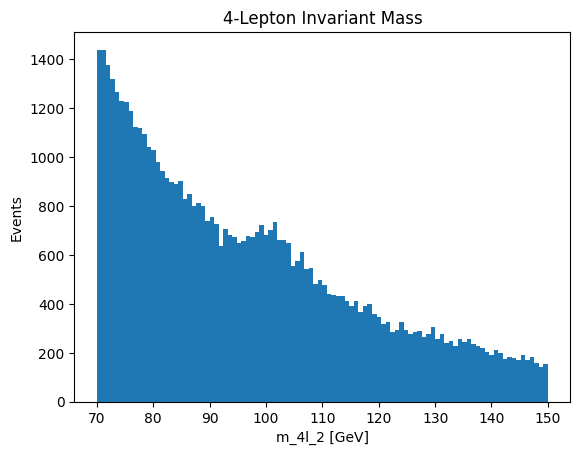

In [13]:
print(f"Calculated masses for {len(m_4l_1)} events.")
print("First 10 mass values:")
print(m_4l_1[:10])

import matplotlib.pyplot as plt
plt.hist(m_4l_1, bins=100, range=(70, 150))
plt.xlabel('m_4l_1 [GeV]')
plt.ylabel('Events')
plt.title('4-Lepton Invariant Mass')
plt.show()

print(f"Calculated masses for {len(m_4l_2)} events.")
print("First 10 mass values:")
print(m_4l_2[:10])

import matplotlib.pyplot as plt
plt.hist(m_4l_2, bins=100, range=(70, 150))
plt.xlabel('m_4l_2 [GeV]')
plt.ylabel('Events')
plt.title('4-Lepton Invariant Mass')
plt.show()

**Note**: using the Friedmann-Draconis rule is again computationally expensive, and perhaps unnecessary.

In [14]:
# Convert the awkward array to a pandas Series
m_4l_1_df = pd.Series(ak.to_numpy(m_4l_1), name='m_4l_2012B_1')
m_4l_2_df = pd.Series(ak.to_numpy(m_4l_2), name='m_4l_2012B_2')

# Export to CSV
m_4l_1_df.to_csv('m_4l_data.csv', index=False)
m_4l_2_df.to_csv('m_42_data.csv', index=False)


print("File 'm_4l_data.csv' has been created successfully.")

File 'm_4l_data.csv' has been created successfully.
